# PyXspec basics – fitting models to data

## Learning Goals

By the end of this tutorial, you will be able to:

- Load X-ray a spectrum and response into PyXspec.
- Define and fit models to X-ray spectra and evaluate their quality.
- Calculate parameter errors and confidence contours.
- Use PyXspec and matplotlib to visualize spectra and model fits.

## Introduction

This example uses some very old spectral data. It's much simpler than more modern
observations and so can be used to better illustrate the basics of XSPEC analysis.

The data in question is a 20 ks EXOSAT 'Medium-Energy' (ME) observation of the
6-second period X-ray pulsar **1E1048.1-5937** by EXOSAT, taken in June 1985.

In this example, we'll conduct a general investigation of the spectrum from the
Medium Energy instrument, i.e. follow the same sort of steps as the original
investigators ([Seward F. D., Charles P. A., Smale A. P. 1986](https://ui.adsabs.harvard.edu/abs/1986ApJ...305..814S/abstract)).

The ME spectrum and corresponding response matrix were obtained from the HEASARC and
are available either as part of a [large collection of example data](https://heasarc.gsfc.nasa.gov/FTP/software/xspec/walkthrough.tar.gz) or directly
from the URLs defined in the [Global Setup: Constants](#constants) section.

### Inputs

- EXOSAT-ME spectrum file for 1E1048.1-5937 - s54405.pha
- Corresponding EXOSAT-ME response file - s54405.rsp

### Outputs

- Various diagnostic plots showing data, models, and residuals
- Best-fit model parameters with uncertainties
- Flux measurements and confidence ranges
- Upper limit on iron emission line equivalent width

### Runtime

As of 28th May 2026, this notebook takes ~1-minute to run to completion on Fornax using the 'small' server with 8GB RAM/2 cores.

## Imports

In [1]:
import contextlib
import os
from time import sleep
from typing import Optional, Tuple
from urllib.request import urlretrieve

import numpy as np
import xspec as xs
from astropy.units import Quantity
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2

## Global Setup

### Functions

In [2]:
def plot_fit_residual_spec(
    plot_data: dict,
    sp_color: str = "navy",
    mod_color: str = "firebrick",
    res_color: str = "navy",
    x_lims: Optional[Tuple[float, float]] = None,
    y_lims: Optional[Tuple[float, float]] = None,
    inst_name: Optional[str] = None,
    stepped_model: bool = True,
    mod_expr: Optional[str] = None,
):
    """
    A convenience function used to plot the spectrum, fitted model, and residuals, at
    various points in this demonstration. The required input is a dictionary of
    the style constructed in various subsections of the 'alternative spectral models'
    section.

    Limited customization of the output figure is offered, but this is not intended
    as a truly general-purpose plotting function, more as a possible inspiration
    for your own versions.

    :param dict plot_data: Dictionary containing all information necessary to produce
        the fitted spectrum and residual visualization.
    :param str sp_color: Matplotlib color to use for the spectral data points.
    :param str mod_color: Matplotlib color to use for the fitted model staircase line.
    :param str res_color: Matplotlib color to use for the residual data points.
    :param Optional[Tuple[float, float]] x_lims: Optional limits on which parts
        of the x-axis to plot. Must be a two-element tuple containing the lower and
        then the upper limit.
    :param Optional[Tuple[float, float]] y_lims: Optional limits on which parts
        of the y-axis to plot. Must be a two-element tuple containing the lower and
        then the upper limit.
    :param str inst_name: Optionally, a mission/instrument name to add to the
        legend label given to the spectral data points.
    :param bool stepped_model: Controls whether the fitted model is plotted as a
        staircase (to match XSPEC's plotting style) or as a smooth line. Default is
        True, resulting in a staircase.
    :param str mod_expr: Optionally, the 'expression' of the fitted model - to be
        added to its legend label.
    """

    # Some basic checks to make sure the plot data is in the right format
    # These are what we need
    req_ents = [
        "energy",
        "energy_delta",
        "rate",
        "rate_err",
        "model",
        "residual",
        "residual_err",
        "energy_step",
    ]
    # Raise an error before we get started plotting if any entries are missing
    if any([en not in plot_data for en in req_ents]):
        raise KeyError(
            f"Plot data must contain the following keys: f{', '.join(req_ents)}"
        )

    # Basic validity check on any axis limits
    if x_lims is not None and (len(x_lims) != 2 or np.diff(x_lims) < 0):
        raise ValueError(
            "Passed x-axis limits must be a two-element tuple, with the first "
            "entry less than the second."
        )
    if y_lims is not None and (len(y_lims) != 2 or np.diff(y_lims) < 0):
        raise ValueError(
            "Passed y-axis limits must be a two-element tuple, with the first "
            "entry less than the second."
        )

    # Determine what the label for spectrum data points should be based on input
    #  instrument name
    sp_label = "Spectral data" if inst_name is None else f"{inst_name} data"

    # Same as above, but for the model label
    mod_label = "Fitted model" if mod_expr is None else f"Fitted model ({mod_expr})"

    fig, ax_arr = plt.subplots(
        nrows=2, figsize=(7, 6), height_ratios=(3, 1.5), sharex=True
    )
    # Shrink the vertical gap between the panels to zero
    fig.subplots_adjust(hspace=0)

    # First axis (the large, top-most one) is where we will plot the spectrum
    #  data points, and fitted model lines.
    spec_ax = ax_arr[0]
    # Turn minor axis ticks on, and configure the direction they point, and that
    #  they also appear on the top and right sides of the plot.
    spec_ax.minorticks_on()
    spec_ax.tick_params(which="both", direction="in", top=True, right=True)

    # First we plot the spectrum data points, including the count rate uncertainty,
    #  and the size of each energy bin as error bars.
    spec_ax.errorbar(
        plot_data["energy"],
        plot_data["rate"],
        xerr=plot_data["energy_delta"],
        yerr=plot_data["rate_err"],
        fmt="+",
        capsize=1.5,
        label=sp_label,
        color=sp_color,
    )

    # If the user has requested that the model fit be shown as a 'stepped' line (i.e.
    #  what the standard XSPEC plots look like), we have to use the 'stairs' method
    #  rather than the standard 'plot' method.
    if stepped_model:
        spec_ax.stairs(
            plot_data["model"],
            plot_data["energy_step"],
            baseline=None,
            fill=False,
            color=mod_color,
            alpha=0.8,
            label=mod_label,
            linewidth=1.4,
            zorder=3,
        )
    # Otherwise, the model will be plotted as a smooth line.
    else:
        spec_ax.plot(
            plot_data["energy"],
            plot_data["model"],
            color=mod_color,
            label=mod_label,
            alpha=0.8,
            linewidth=1.4,
            zorder=3,
        )

    # We allow the user to set specific x and y axis limits when they call this
    #  function - if they have passed limits, we enforce them here (the residual
    #  axis will inherit the limits as well, because we set sharex=True when
    #  we defined the figure.
    if x_lims is not None:
        spec_ax.set_xlim(x_lims)
    if y_lims is not None:
        spec_ax.set_ylim(y_lims)

    # We just assume the user wants a logged y-scale, which I don't think is too
    #  restrictive.
    spec_ax.set_yscale("log")
    # Alter the formatting of the labels so that they are 0.1, 0.01, 0.001 etc.
    spec_ax.yaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))
    # And make sure to set the y-axis label
    spec_ax.set_ylabel(
        r"Spectrum [$\frac{\rm{ct}}{\rm{s} \: \rm{cm}^{2} \: \rm{keV}}$]", fontsize=15
    )

    spec_ax.legend(fontsize=14)

    res_ax = ax_arr[1]
    res_ax.minorticks_on()
    res_ax.tick_params(which="both", direction="in", top=True, right=True)

    res_ax.errorbar(
        plot_data["energy"],
        plot_data["residual"],
        xerr=plot_data["energy_delta"],
        yerr=plot_data["residual_err"],
        fmt="+",
        capsize=1.5,
        color=res_color,
    )
    res_ax.axhline(0, color="goldenrod", linestyle="dashed")

    res_ax.set_xlabel("Energy [keV]", fontsize=15)
    res_ax.set_ylabel(
        r"Residuals [$\frac{\rm{ct}}{\rm{s} \: \rm{cm}^{2} \: \rm{keV}}$]", fontsize=15
    )

    res_ax.set_xscale("log")
    res_ax.xaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))
    res_ax.xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))

    plt.show()

### Constants

In [3]:
SRC_NAME = "1E1048.1-5937"

EXOSAT_ME_SP_BASE_URL = "https://nasa-heasarc.s3.amazonaws.com/exosat/data/me/spectra"
DEMO_SPEC_URL = os.path.join(EXOSAT_ME_SP_BASE_URL, "s54405.pha.Z")
DEMO_RESP_URL = os.path.join(EXOSAT_ME_SP_BASE_URL, "s54405.rsp.Z")

### Configuration

In [4]:
# ------------- Setting how many cores we can use --------------
# We use a service called CircleCI to execute, test, and validate these notebooks
#  as we're writing and maintaining them. Unfortunately we have to treat the
#  determination of the number of cores we can use differently, as the
#  'os.cpu_count()' call will return the number of cores of the host machine, rather
#  than the number that have actually been allocated to us.
if "CIRCLECI" in os.environ and bool(os.environ["CIRCLECI"]):
    # Here we read the CPU quota (total CPU time allowed) and the CPU period (how
    #  long the scheduling window is) from a cgroup (a linux kernel feature) file.
    # Dividing one by t'other provides the number of cores we've been allocated.
    with open("/sys/fs/cgroup/cpu.max", "r") as cpu_maxo:
        quota, period = cpu_maxo.read().strip().split()
        NUM_CORES = int(quota) // int(period)

# If you, the reader, are running this notebook yourself, this is the
#  part that is relevant to you - you can override the default number of cores
#  used by setting this variable to an integer value.
else:
    NUM_CORES = None

# Determines the number of CPU cores available
total_cores = os.cpu_count()

# If NUM_CORES is None, then we use the number of cores returned by 'os.cpu_count()'
if NUM_CORES is None:
    NUM_CORES = total_cores
# Otherwise, NUM_CORES has been overridden (either by the user, or because we're
#  running on CircleCI, and we do a validity check.
elif not isinstance(NUM_CORES, int):
    raise TypeError(
        "If manually overriding 'NUM_CORES', you must set it to an integer value."
    )
elif isinstance(NUM_CORES, int) and NUM_CORES > total_cores:
    raise ValueError(
        f"If manually overriding 'NUM_CORES', the value must be less than or "
        f"equal to the total available cores ({total_cores})."
    )
# --------------------------------------------------------------

# -------------- Set paths and create directories --------------
if os.path.exists("../../../_data"):
    ROOT_DATA_DIR = "../../../_data/PyXSPEC/EXOSAT"
else:
    ROOT_DATA_DIR = "PyXSPEC/EXOSAT"

# Ensure that the specified directory exists
ROOT_DATA_DIR = os.path.abspath(ROOT_DATA_DIR)

# Make sure the download directory exists.
os.makedirs(ROOT_DATA_DIR, exist_ok=True)
# --------------------------------------------------------------

# ------------- Download demonstration data files --------------
# Download the spectrum and response required for this demonstration.
#  The return value is unimportant, and we only capture it in a variable to
#  avoid Jupyter notebooks from printing it, as these are the last lines of the cell.
# The EXOSAT-ME spectrum
ret = urlretrieve(
    DEMO_SPEC_URL, os.path.join(ROOT_DATA_DIR, os.path.basename(DEMO_SPEC_URL))
)
# The accompanying EXOSAT-ME response
ret = urlretrieve(
    DEMO_RESP_URL, os.path.join(ROOT_DATA_DIR, os.path.basename(DEMO_RESP_URL))
)
# --------------------------------------------------------------

***

## 1. Loading a spectrum into PyXspec

The spectral files we need for this demonstration were downloaded
in the [Global Setup: Configuration](#configuration) section.

We can read our spectrum file into a PyXspec `Spectrum` object, assigning it
to the `exo_me_spec`variable. **Most** PyXspec operations don't involve
direct interaction with individual spectrum objects, but we will use it to ignore
some channels later in this tutorial.

The spectrum file we are using for this demonstration has not been downloaded to the
same directory as the notebook, so we will briefly change our working directory as we
load it.

Of course, we could pass the full spectrum path rather than changing
directories, but the 'RESPFILE' entry in the spectrum's header is a path relative
to the location of the spectrum file.

As such, if we didn't change directories, PyXspec would have been unable to find and
automatically load the response file (though we _could_ instead pass a response
file path to the optional `respfile` argument of the `Spectrum` constructor).

In [5]:
with contextlib.chdir(ROOT_DATA_DIR):
    exo_me_spec = xs.Spectrum("s54405.pha")

Creating a $HOME/.xspec directory for you
***Warning: Unrecognized grouping for channel(s). It/they will be reset to 1.
  HOWEVER NOTE: Resets only occurred for channels of bad quality

1 spectrum  in use
 
Spectral Data File: s54405.pha  Spectrum 1
Net count rate (cts/s) for Spectrum:1  3.783e+00 +/- 1.367e-01
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-125
  Telescope: EXOSAT Instrument: ME  Channel Type: PHA
  Exposure Time: 2.358e+04 sec
 Using fit statistic: chi
 Using Response (RMF) File            s54405.rsp for Source 1


***Warning: POISSERR keyword is missing or of wrong format, assuming FALSE.


## 2. Visualizing the data

One of the first things most users will want to do at this stage - even before fitting
a model - is to look at their data (something we strongly encourage as a first
step of _any_ analysis).

XSPEC can plot a wide variety of different information, all related in some way to
the underlying spectral data, fitted model(s), fit statistics, and the instrument
used to collect the data.

Even though we're using the Python interface to XSPEC and will be creating
visualizations using Matplotlib, we can still take advantage of XSPEC's backend
plotting functionality by retrieving the data necessary to create
a particular figure from PyXspec.

The exact visualization information that can be retrieved from PyXspec will depend on
what you're plotting, but here follow some examples of what can be fetched:
- X and Y data points.
- X and Y uncertainties.
- Axis labels.
- Plot title.

### What plots can XSPEC generate?

To list the types of plots that PyXspec can generate, we can run:

In [6]:
xs.Plot("?")

plot data/models/fits etc
    Syntax: plot commands:
	background     chain          chisq          contour        counts         
	data           delchi         dem            edata          eedata         
	eemodel        eeufspec       efficiency     emodel         eqw            
	eufspec        fitstat        foldmodel      goodness       icounts        
	insensitivity  integprob      lcounts        ldata          ledata         
	leedata        margin         model          polangle       polfrac        
	ratio          residuals      sensitivity    sum            ufspec         
	
    Multi-panel plots are created by entering multiple options e.g. data fitstat


### Setting XSPEC's plot device

Before we actually plot something, we need to set the 'plot device' that XSPEC's
graphic library outputs to. When running XSPEC 'traditionally' (i.e. through
the command line), then your choice of plot device will control whether a figure is
written to a file or displayed in a window (and what technology/file format is utilized).

In this demonstration we don't really want either of those things to happen, as we're
going to use the Python module **matplotlib** to do our own plotting. As such, we
set the plot device to "/null", which means that XSPEC won't output figures at all:

In [7]:
xs.Plot.device = "/null"

```{danger}
Skipping this step could result in many files being written to your current
directory, or the wholesale failure of all plotting in your notebook.
```

### Plotting a spectrum

The **data** plot option produces the most important of all XSPEC visualizations – a
spectrum!

By default, spectra will be plotted as a function of **instrument channel**, which
is the most fundamental indication of an X-ray event's energy (said event hopefully
corresponding to a _photon_, as opposed to a particle, hitting the detector).

On the other hand, if an instrument _response_ has been loaded along with the spectral data (we
made sure of that [Section 1](#1-loading-a-spectrum-into-pyxspec)), then we can plot
the spectrum as a function of **energy** (considerably more useful).

Note, however, that this won't happen automatically just because a response is
available; we have to specify the units of the energy axis explicitly:

In [8]:
xs.Plot.xAxis = "keV"

As we've already mentioned, we're going to use the Python module **matplotlib** to
construct our figures and visualizations. Compared to using XSPEC's intrinsic plotting
functionality, this will give us a great deal of flexibility and much finer control
over the final figure.

Our first task is to use PyXspec to produce the rate, energy, and uncertainty
information that make up a spectrum visualization, then to retrieve the data
to pass to matplotlib.

Here we call the `Plot` method, passing **"data"** to specify which type of plot XSPEC
should produce (in this case a spectrum). Note that **preparing** and **retrieving** the
data necessary to visualize a PyXspec plot with Matplotlib are **two distinct steps**:

1. Running `Plot("data")` will recalcuate plot quantities based on the current data, noticed channels, model fit (if any), etc.
2. Calling `Plot.x()` or `Plot.y()` will **fetch** the most current calculated quantities.

You will also notice that PyXspec very handily provides the axis labels and title that
it would use if it were making the plot itself, we store those too:

In [9]:
xs.Plot("data")

spec_plot_data = {
    "energy": np.array(xs.Plot.x()),
    "energy_delta": np.array(xs.Plot.xErr()),
    "rate": np.array(xs.Plot.y()),
    "rate_err": np.array(xs.Plot.yErr()),
    "x_label": xs.Plot.labels()[0],
    "y_label": xs.Plot.labels()[1],
    "title": xs.Plot.labels()[2],
}

```{tip}
If you're working in a Jupyter notebook, and are likely to be making multiple versions
of XSPEC plots, we recommend storing plot data in a dictionary, as we have
demonstrated above.

This helps reduce the risk of accidentally re-using variable names and overwriting their
existing values, or using plot data from a previous figure. As Jupyter notebooks can
be run out of order, or have cells re-executed, this is an important consideration.
```

All that information can now be used to construct a figure showing the spectrum, prior to
any fitting or energy limits, whilst making some small customizations to improve
the appearance and clarity of the plot.

In this particular case, this includes:
- Logging the energy axis; `plt.xscale("log")`
- Configuring axis ticks to point inwards and be present on the top and right of the figure; `plt.tick_params(which="both", direction="in", top=True, right=True)`
- Removing labels from minor ticks on the energy axis if the values are below 1 keV, to avoid colliding labels; `ax.xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp) if inp >= 1 else ""))`

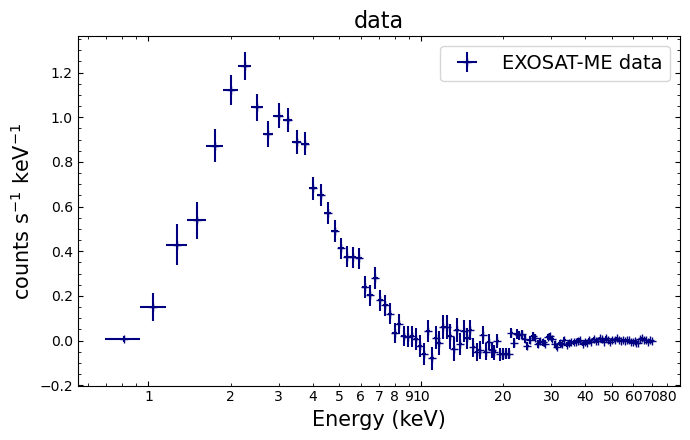

In [10]:
plt.figure(figsize=(7, 4.5))
plt.minorticks_on()
plt.tick_params(which="both", direction="in", top=True, right=True)

plt.errorbar(
    spec_plot_data["energy"],
    spec_plot_data["rate"],
    xerr=spec_plot_data["energy_delta"],
    yerr=spec_plot_data["rate_err"],
    fmt="+",
    label="EXOSAT-ME data",
    color="navy",
)

plt.xscale("log")

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda inp, _: "{:g}".format(inp) if inp >= 1 else "")
)

plt.xlabel(spec_plot_data["x_label"], fontsize=15)
plt.ylabel(spec_plot_data["y_label"], fontsize=15)

plt.title(spec_plot_data["title"], fontsize=16)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## 3. Defining and fitting models

We are now ready to fit the data with a model.

Models in XSPEC are specified using the `model` command, followed by an algebraic
expression of a combination of component models.

There are two basic kinds of model components – **additive** and **multiplicative**:
- **Additive components** – Represent X-Ray sources of different kinds (e.g., a bremsstrahlung continuum) and, after being convolved with the instrument response, prescribe the number of counts per energy bin.
- **Multiplicative components** – Represent phenomena that modify the observed X-Radiation (e.g. reddening or an absorption edge). They apply an energy-dependent multiplicative factor to the source radiation before the result is convolved with the instrumental response.

More generally, XSPEC allows three types of **modifying** components:
- The **multiplicative** type mentioned above.
- **Convolutions**, which apply a convolution operator to an input model calculated from another model (e.g. _cgflux_, which we use [in Section 5](#5-flux-calculation)).
- **Mixing models**, which perform transformations on the available spectra (e.g. modeling cross-talk between spatial regions of a detector/source).


Since there must be a source, there must be **at least one additive component model**, but
there is no restriction on the number of modifying components.

### Setting up a model object

Given the fairly low quality of our data, as shown by [the plot above](#plotting-a-spectrum), we'll
choose an **absorbed power law**. To set it up, we define an instance of the PyXspec
`Model` class and assign it to a variable - `abs_pl_mod`:

In [11]:
abs_pl_mod = xs.Model("tbabs(powerlaw)")


Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Fit statistic  : Chi-Squared              4.867896e+08     using 125 bins.

### Ignoring bad channels

We are not quite ready to fit the data (and obtain a better $\chi^2$), because some
of the 125 PHA bins should not be included in the fitting:

- Some are below the lower discriminator of the instrument and therefore do not contain valid data.
- Some have imperfect background subtraction at the margins of the pass band.
- Some may not contain enough counts for $\chi^2$ to be strictly meaningful.

To find out which channels to discard (ignore in XSPEC terminology), consult
mission-specific documentation that will include information about discriminator
settings, background subtraction problems, and other issues.

For the mature missions in the HEASARC archives, this information may have already been
encoded in the headers of the spectral files as a list of bad channels. To remove the
bad channels from the spectrum that we
[previously read into `exo_me_spec`](#1-loading-a-spectrum-into-pyxspec), we can use:

In [12]:
xs.AllData.ignore("bad")


ignore:    40 channels ignored from  source number 1
Fit statistic  : Chi-Squared              4.867277e+08     using 85 bins.

Test statistic : Chi-Squared              4.867277e+08     using 85 bins.
 Null hypothesis probability of 0.000000e+00 with 82 degrees of freedom
 Current data and model not fit yet.


```{note}
PyXspec doesn't allow us to ignore "bad" channels for individual spectra, only for
**all loaded spectra**. `AllData` is a special data manager object which allows us
to perform operations on all current spectra.
```

### Renormalizing the model to our data

The **current statistic is $\chi^2$**, and is huge for the initial, default, model
parameter values – mostly because the power law normalization is **two orders of
magnitude too large**. This particular problem is easily fixed using the renorm method:

In [13]:
xs.Fit.renorm()


Fit statistic  : Chi-Squared                  796.59     using 85 bins.

Test statistic : Chi-Squared                  796.59     using 85 bins.
 Null hypothesis probability of 1.46e-117 with 82 degrees of freedom
 Current data and model not fit yet.


### Visualizing the spectrum and renormalized model

To show off our renormalized, but not yet fit, model, we'll use PyXspec and
matplotlib together to produce a two-panel figure. The top panel will show
the spectral data and the current state of the model, and the bottom panel will
show $\Delta\chi^2$ values given the sign of the corresponding residual value.

Just like in [Section 2](#plotting-a-spectrum), we can use the PyXspec `Plot` manager
object to calculate the information necessary to plot our spectrum, model, and signed
$\Delta\chi^2$.

Passing two choices to the `Plot` object generates a plot with vertically stacked
'plot windows' (up to a maximum of six panels). The plot data
calculated for each plot option can be accessed by passing an index to the
`plotWindow=...` argument of `Plot`'s various methods.

```{tip}
Remember that XSPEC (and thus PyXspec) uses 'one-based indexing' (as opposed to
Python's zero-based indexing), so to retrieve the data relevant to the bottom panel, we
need to pass `plotWindow=2`, and `plotWindow=1` for the top panel.
```

We read out the spectral rates and errors, energy bin centers and half-widths, the
current rates of the model at each energy bin center, and the signed $\Delta\chi^2$
values calculated for the bottom panel – storing them in a dictionary. Additionally, the
axis labels that XSPEC _would_ have used are stored in the same dictionary.

In this instance we're going to imitate the appearance of an XSPEC fitted spectrum
plot, so rather than plotting the model as a **smooth line**, we'll display it as a
**staircase**. This being a visual reminder that the model is only evaluated at the
centers of the energy bins.

To support the staircased model line, we calculate the upper and lower edges of
each energy bin by subtracting the energy bin half-widths from the energy bin centers
and appending a final bin edge representing the last energy bin center plus
its half-width:

In [14]:
xs.Plot("data chi")

rn_mod_plot_data = {
    "energy": np.array(xs.Plot.x(plotWindow=1)),
    "energy_delta": np.array(xs.Plot.xErr(plotWindow=1)),
    "rate": np.array(xs.Plot.y(plotWindow=1)),
    "rate_err": np.array(xs.Plot.yErr(plotWindow=1)),
    "model": np.array(xs.Plot.model(plotWindow=1)),
    "signed_chisq": np.array(xs.Plot.y(plotWindow=2)),
    "x_label": xs.Plot.labels(plotWindow=1)[0],
    "y_label": xs.Plot.labels(plotWindow=1)[1],
    "chisq_label": xs.Plot.labels(plotWindow=2)[1],
}

rn_mod_plot_data["energy_step"] = np.append(
    rn_mod_plot_data["energy"] - rn_mod_plot_data["energy_delta"],
    rn_mod_plot_data["energy"][-1] + rn_mod_plot_data["energy_delta"][-1],
)

***Warning: Fit is not current.


```{attention}
We get a warning that the fit is not current because no fit has been performed
yet (renormalizing doesn't count, the reason for which will become obvious when you
see the figure).
```

As a brief aside, we can examine the XSPEC-generated label for the y-axis of the
upcoming figure's lower panel, as we won't actually be using it in our
visualization.

We're discarding the default label for practical purposes, as it is too long for
the small amount of space we give to the lower panel.

However, as you can see, the meanings of the original and our replacement are
equivalent. You will also notice that XSPEC produces LaTeX-formatted labels
suitable for use with matplotlib:

In [15]:
rn_mod_plot_data["chisq_label"]

'sign(data-model) $\\times$ $\\Delta$ $\\chi$$^{2}$'

Finally, we can make our visualization:

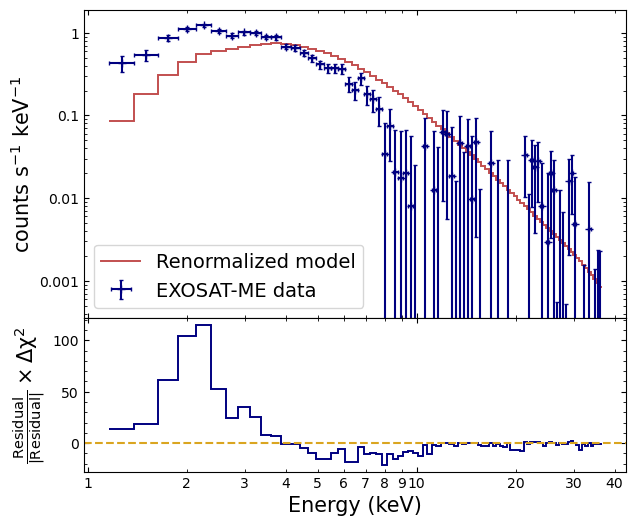

In [16]:
fig, ax_arr = plt.subplots(nrows=2, figsize=(7, 6), height_ratios=(3, 1.5), sharex=True)
# Shrink the vertical gap between the panels to zero
fig.subplots_adjust(hspace=0)

spec_ax = ax_arr[0]
spec_ax.minorticks_on()
spec_ax.tick_params(which="both", direction="in", top=True, right=True)

spec_ax.errorbar(
    rn_mod_plot_data["energy"],
    rn_mod_plot_data["rate"],
    xerr=rn_mod_plot_data["energy_delta"],
    yerr=rn_mod_plot_data["rate_err"],
    fmt="+",
    capsize=1.5,
    label="EXOSAT-ME data",
    color="navy",
)

spec_ax.stairs(
    rn_mod_plot_data["model"],
    rn_mod_plot_data["energy_step"],
    baseline=None,
    fill=False,
    color="firebrick",
    alpha=0.8,
    label="Renormalized model",
    linewidth=1.4,
)

spec_ax.set_xscale("log")
spec_ax.xaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))
spec_ax.xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))

spec_ax.set_yscale("log")
spec_ax.yaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))

spec_ax.set_ylabel(rn_mod_plot_data["y_label"], fontsize=15)

spec_ax.legend(fontsize=14)

chi_ax = ax_arr[1]
chi_ax.minorticks_on()
chi_ax.tick_params(which="both", direction="in", top=True, right=True)

chi_ax.stairs(
    rn_mod_plot_data["signed_chisq"],
    rn_mod_plot_data["energy_step"],
    baseline=None,
    fill=False,
    color="navy",
    linewidth=1.4,
)

chi_ax.axhline(0, color="goldenrod", linestyle="dashed")

chi_ax.set_xlabel(rn_mod_plot_data["x_label"], fontsize=15)
chi_ax.set_ylabel(
    r"$\frac{\rm{Residual}}{|\rm{Residual}|} \: \times \: \Delta\chi^2$", fontsize=15
)

plt.show()

### Ignoring channels based on energy

Forty channels were rejected in [a previous section](#ignoring-bad-channels) because
they were flagged as **bad** – but do we need to ignore any more?

The [renormalized model figure](#visualizing-the-spectrum-and-renormalized-model) shows
the result of plotting the data and the model (in the upper window) and the
contributions to $\chi^2$ (in the lower window).

We see that above about 15 keV the signal-to-noise becomes small. We also see, when
comparing with our [initial spectrum figure](#plotting-a-spectrum), which bad
channels were ignored.

Although visual inspection is not the most rigorous method for deciding which
channels to ignore, it's good enough for now and will at least prevent us from
getting grossly misleading fit results. To ignore energies above 15 keV:

In [17]:
exo_me_spec.ignore("15.0-**")

    78 channels (48-125) ignored in spectrum #     1

Fit statistic  : Chi-Squared                  718.42     using 45 bins.

Test statistic : Chi-Squared                  718.42     using 45 bins.
 Null hypothesis probability of 5.53e-124 with 42 degrees of freedom
 Current data and model not fit yet.


```{caution}
Note that `ignore` (and `notice`) interpret **integers as channel numbers** and ***real
numbers as energies*** - it can be confusing when you think you've ignored everything
above 8 keV but instead find you only have 8 channels.

Also, the double star (\*\*) is a special indicator which just means the
extreme value in the spectrum - in this case the upper extreme, but if we instead
ran `ignore("**-15.0")` we'd ignore everything **up to** 15 keV.
```

### Preparing to fit the model

We are now ready to fit the data. Fitting is initiated by the command xs.Fit.perform().

As the fit proceeds, the screen displays the status of the fit for each iteration
until either the fit converges to the minimum $\chi^2$, or the maximum number of
iterations is exceeded.

The current maximum number of iterations can be found like this:

In [18]:
print(xs.Fit.nIterations)

10


We can also set a new maximum number of iterations using the same `Fit` attribute:

In [19]:
xs.Fit.nIterations = 50

### Performing the model fit

In [20]:
xs.Fit.perform()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    2:PhoIndex        3:norm
451.747      150.716      -3     0.0934254       1.60966    0.00387228
413.31       63193.6      -3      0.272618       2.30612    0.00909560
54.0828      28059.8      -4      0.521485       2.14066     0.0121325
43.8345      4672.39      -5      0.556743       2.23842     0.0130769
43.8215      131.89       -6      0.543800       2.23583     0.0130241
43.8214      0.582959     -7      0.542814       2.23549     0.0130166
 Variances and Principal Axes
                 1        2        3  
 4.7777E-08| -0.0025  -0.0151   0.9999  
 2.3010E-03|  0.3979  -0.9173  -0.0128  
 8.8416E-02|  0.9174   0.3978   0.0083  
----------------------------------------

  Covariance Matrix
        1           2           3   
   7.478e-02   3.143e-02   6.623e-04
   3.143e-02   1.593e-02   3.194e-04
   6.623e-04   3.194e-04   6.532e-06
------------------------------------

Model TBabs<1>*po

451.747      150.716      -3     0.0934254       1.60966    0.00387228
413.31       63193.6      -3      0.272618       2.30612    0.00909560
54.0828      28059.8      -4      0.521485       2.14066     0.0121325
43.8345      4672.39      -5      0.556743       2.23842     0.0130769
43.8215      131.89       -6      0.543800       2.23583     0.0130241
43.8214      0.582959     -7      0.542814       2.23549     0.0130166
 Variances and Principal Axes
                 1        2        3  
 4.7777E-08| -0.0025  -0.0151   0.9999  
 2.3010E-03|  0.3979  -0.9173  -0.0128  
 8.8416E-02|  0.9174   0.3978   0.0083  
----------------------------------------

  Covariance Matrix
        1           2           3   
   7.478e-02   3.143e-02   6.623e-04
   3.143e-02   1.593e-02   3.194e-04
   6.623e-04   3.194e-04   6.532e-06
------------------------------------

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs    

### Interpreting the output of an XSPEC fit

There is a fair amount of information here, so we will unpack it a bit at a time.

#### State of the fit at each iteration [first section]

XSPEC writes out one line after each fit iteration, containing the following:
- Two obvious columns:
  - **Chi-Squared**
  - **Parameters**
- As well as two less obvious columns related to fit convergence:
    - **|beta|/N** – At each step in the fit a numerical derivative of the statistic with respect to the parameters is calculated. We call the vector of these derivatives 'beta'.
    - **Lvl** – A measure of the Levenberg–Marquardt algorithm's (the default XSPEC fitting method) 'damping parameter' indicating how the fit is converging (it should generally decrease).


At the best-fit the normalization of beta should be **zero**, so XSPEC displays |beta|
divided by the number of parameters (N) as a check of that.

The actual default convergence criterion is when the fit statistic does not change
significantly between iterations, so bear in mind that it is possible for the fit to
end while |beta| is still significantly different from zero.

```{note}
For the first iteration only the powerlaw normalization is varied.

While not strictly necessary this simple model, for more complicated models only
varying the norms on the first iteration helps the fit proper get started in a
reasonable region of parameter space.
```

#### Fitting statistics [second section]

Once the fit has finished its iterations, PyXspec writes out the
"Variances and Principal Axes" and "Covariance Matrix" tables. These are both based
on the second derivatives of the fit statistic with respect
to the parameters. Generally, the larger these second derivatives, the better
determined the parameter (think of the case of a parabola in 1-D).

The "Covariance Matrix" table is the inverse of the matrix of second derivatives.

The "Variances and Principal Axes" section is based on an eigenvector decomposition of the
second derivative matrix and indicates which parameters are correlated. We can see that
in this case that the first eigenvector depends almost entirely on
the powerlaw normalization, while the other two are combinations of the _nH_ and
powerlaw _PhoIndex_. This tells us that the normalization is independent, but that the **other two
parameters are correlated**.


#### Best-fit model parameters and error _estimates_ [third section]

After the "Covariance Matrix" section, the next table shows the best-fit model
parameters and their error _estimates_. The latter are just the square roots of
the covariance matrix's diagonal elements (i.e. the **variance** elements) – as
such they implicitly assume that the parameter space is multidimensional Gaussian
with all parameters independent.

We **already know that in this case the parameters are not independent**, so
these error estimates should only be considered guidelines to help us determine
[the true errors later](#4-error-analysis).


#### Final statistic values [fourth section]

The fourth and final section displays the statistic values at the end of the fit.

PyXspec defines a fit statistic, used to determine the best-fit parameters and
errors, and test statistic, used to decide whether this model and parameters
provide a good fit to the data.

By default, both statistics are $\chi^2$ – when the test statistic is $\chi^2$, we
can also calculate the null hypothesis probability (as you can see in the fit output).

The null hypothesis probability is the likelihood of getting a value of $\chi^2$ as
large or larger than observed if the model is correct, and **if this probability is
small, then the model is not a good fit**.


### Examining goodness of fit without a null hypothesis probability

The null hypothesis probability can be calculated analytically for the $\chi^2$
statistic and, if you haven't selected a different test statistic, XSPEC will
do so during model fits, as we [saw in the last section](#final-statistic-values-fourth-section).

Unfortunately, there is no way to analytically calculate the null hypothesis
probability for some of the other test statistics that XSPEC offers, so we need
another way to determine the meaning of the statistic value.

PyXspec has a built-in function that will perform simulations of the data based on
the current model and parameters, then compare the statistic values of the simulation
to that calculated for the real data. If the observed statistic is larger than the
values calculated for the simulated data, then the implication is that the real data
do not come from the current model.

Before we run the `Fit.goodness(...)` function, we will make our first use of XSPEC's
parallelization capabilities, intended to improve the performance of certain tasks by
utilizing multiple cores (many-core CPUs are now almost ubiquitous). This demonstration
notebook determined the number of cores available in the [Global Setup: Configuration](#configuration)
section, and stored the number in the `NUM_CORES` constant.

Here we specifically set the `goodness` function to use all available cores:

In [21]:
xs.Xset.parallel.goodness = NUM_CORES

Now we can run the command, which will display a one-line message passing judgement
on the current model's goodness (or lack thereof); it also returns the percentage of
simulations that had a smaller test statistic than the observed data. While we're
at it, we retrieve the distribution of simulation test statistics for later use:

In [22]:
cur_lt_stat_perc = xs.Fit.goodness(1000)
# This just splits off the XSPEC output from the other output we show below
print("--------------------------------------------------------------------", "\n")
cur_test_stat = xs.Fit.testStatistic

# The 'previousGoodnessSims' attribute returns a list of strings - they
#  must be converted to floats before we make a histogram.
goodness_dist = np.array(xs.Fit.previousGoodnessSims).astype(float)
goodness_dist[:20]

58.80% of realizations are < best test statistic 43.82  (nosim)  (fit)
--------------------------------------------------------------------


-------------------------------------------------------------------- 



array([17.8307483 , 19.62602409, 20.76426273, 21.30913168, 21.83650857,
       22.01511059, 22.18381599, 23.12378947, 23.28502316, 23.48332704,
       23.58972276, 23.59922549, 23.77314561, 24.32848021, 24.38381696,
       24.69270837, 24.69909351, 24.79786295, 25.23509332, 25.45735167])

```{warning}
We retrieve the goodness-of-fit distribution in the same cell as the call to the
`goodness()` method to ensure that no other fit or goodness calculation has been
run in between _this_ goodness call and the _retrieval_.

This might happen if, for instance, you are running the notebook out of order - as the
goodness-of-fit distribution is stored in the global fit manager, rather than a unique
model object, it could be overridden.
```

Approximately 60% of the simulations give a statistic value less than that
observed, consistent with this being a good fit. We might now want to plot a
histogram of the $\chi^2$ values from the simulations, with the observed statistic
value shown as a vertical line, for context.

It is entirely possible to retrieve the bin centers and probability density values
from PyXspec and use them with matplotlib to reconstruct the histogram that XSPEC
would make – just as we've been doing for other visualizations.

Taking that route for a histogram is a little awkward, however, so why don't we
instead directly use the goodness-of-fit value distribution to construct and plot
a histogram.

We actually already retrieved the goodness-of-fit distribution, in the same cell we ran
the `goodness()` method, so creating a histogram is straightforward:

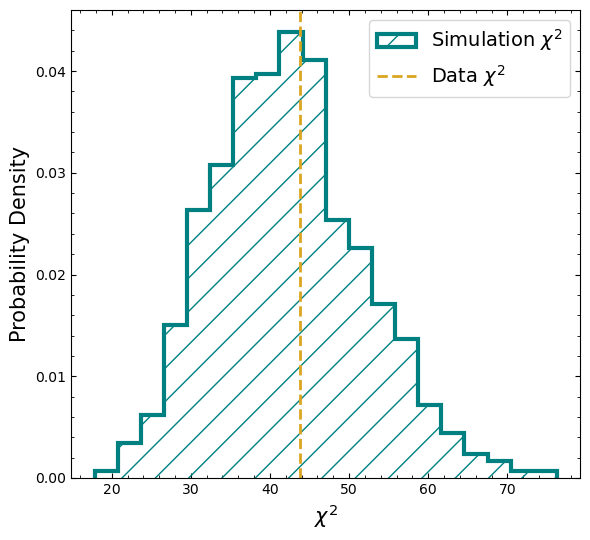

In [23]:
plt.figure(figsize=(6, 5.5))
plt.minorticks_on()
plt.tick_params(which="both", direction="in", top=True, right=True)

plt.hist(
    goodness_dist,
    bins=20,
    density=True,
    ec="teal",
    histtype="step",
    hatch="/",
    linewidth=3,
    label=r"Simulation $\chi^{2}$",
)

plt.axvline(
    cur_test_stat,
    linestyle="dashed",
    color="goldenrod",
    linewidth=2,
    label=r"Data $\chi^{2}$",
)

plt.xlabel(r"$\chi^2$", fontsize=15)
plt.ylabel("Probability Density", fontsize=15)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### Examining fit residuals

So the statistic implies the fit is good, but it is still always a good idea to look
at the data and residuals to check for any systematic differences that may not be
caught by the test.

We pull the relevant information out of PyXspec in a similar manner to our earlier
plot of [the renormalized, unfit, model earlier](#visualizing-the-spectrum-and-renormalized-model),
though here we pass "data resid" rather than "data chi":

In [24]:
xs.Plot("data resid")

fit_pl_plot_data = {
    "energy": np.array(xs.Plot.x(plotWindow=1)),
    "energy_delta": np.array(xs.Plot.xErr(plotWindow=1)),
    "rate": np.array(xs.Plot.y(plotWindow=1)),
    "rate_err": np.array(xs.Plot.yErr(plotWindow=1)),
    "model": np.array(xs.Plot.model(plotWindow=1)),
    "residual": np.array(xs.Plot.y(plotWindow=2)),
    "residual_err": np.array(xs.Plot.yErr(plotWindow=2)),
}

fit_pl_plot_data["energy_step"] = np.append(
    fit_pl_plot_data["energy"] - fit_pl_plot_data["energy_delta"],
    fit_pl_plot_data["energy"][-1] + fit_pl_plot_data["energy_delta"][-1],
)

We can now visualize our data, fitted model, and residuals by calling a convenience
function that was defined in the [Global Setup: Functions](#functions) section. Said
function contains plotting code that is quite similar to what we wrote for
[the last spectrum figure](#visualizing-the-spectrum-and-renormalized-model), but
seeing as we'll be wanting to make a few of these plots, it is neater to
put into a function:

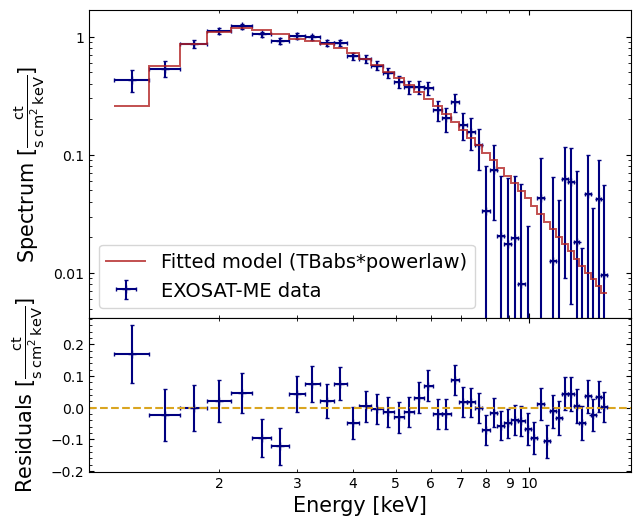

In [25]:
plot_fit_residual_spec(
    fit_pl_plot_data, inst_name="EXOSAT-ME", mod_expr=abs_pl_mod.expression
)

## 4. Error analysis

Now that we think we have an acceptable model, we need to determine how well the
parameters are constrained.

You may recall that the output at the end of XSPEC's fitting process (see
[this summary of its contents](#best-fit-model-parameters-and-error-estimates-third-section))
shows the best-fitting parameter values, and **approximations** to their errors. Those
errors should be regarded only as _indications_ of the parameter uncertainties and should
absolutely **not be quoted in publications**.

### XSPEC's `error()` method

The true errors, i.e. the confidence ranges, are obtained using the `Fit.error()` method.

We want to run `error()` on all three parameters of our model, which is an intrinsically
parallel operation, so we can once again use PyXspec's support for multiple cores and
run the error estimations in parallel.

The numbers 1, 2, 3 refer to the IDs assigned to each parameter by XSPEC. You
can check which ID goes with which parameter by passing the IDs to our model object:

In [26]:
print(abs_pl_mod(1).name, abs_pl_mod(2).name, abs_pl_mod(3).name)

nH PhoIndex norm


Now we run the error calculation:

In [27]:
xs.Xset.parallel.error = NUM_CORES
xs.Fit.error("1-3")

 Parameter   Confidence Range (2.706)
     1     0.107662      1.01753    (-0.43511,0.474755)
     2      2.03713      2.44776    (-0.198347,0.212282)
     3   0.00953337    0.0181336    (-0.00348297,0.0051173)


Examining the output of the `error()` method we see that for the first parameter, the
column density of absorbing hydrogen atoms, the 90% confidence range is 0.110–1.018.

More usefully, we can dynamically retrieve error values calculated for specific
parameters from the XSPEC model object:

In [28]:
# Can access the nH parameter instance by passing its ID to the model
print(abs_pl_mod(1).error, "\n")

# Or by accessing the nH attribute of the model's TBabs attribute
print(abs_pl_mod.TBabs.nH.error)

(0.10766234087236387, 1.017527160754112, 'FFFFFFFFF') 

(0.10766234087236387, 1.017527160754112, 'FFFFFFFFF')


The first entry in the returned tuple is the lower confidence limit, the second is the
upper confidence limit, and the third is the **nine-letter error string** that
indicates whether the error calculation was successful (**FFFFFFFFF** means that we're
all good; see the 'error' entry in the [XSPEC `tclout` API reference](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/node60.html#tclout)
for full information).

```{tip}
When you pass only a set of parameters to `error()`, and no other arguments, you are
determining the 90% confidence interval - a $\Delta\chi^{2}$ of 2.706.

It is of course possible to tell XSPEC to calculate a different confidence level. You
can pass a delta fit statistic calculated from a **one degree of freedom** $\chi^2$
distribution ([see the next section for an easy way to do this in Python](#running-steppar-to-explore-parameter-correlations))
to the `error()` method. For the 68.3% ($1\sigma$) confidence levels of all three
parameters we would use `error("1.0 1-3")`, for 95.5% ($2\sigma$) - `error("4.034 1-3")`,
and for 99.7% ($3\sigma$) - `error("9.0 1-3")`
```

You might ask why these better error calculations are not performed automatically, as
part of the standard fitting process – the answer to that question is that they entail
further fitting. When the model is simple (as in our example), this requires
little CPU time, but for complicated models the extra time can be quite considerable.

The error for each parameter is determined by allowing all other, unfrozen, model
parameters to vary freely, and if model parameters are uncorrelated then this error is
all we need to know.

Remember, though, that we have an indication from the fit process's
[output covariance matrix](#fitting-statistics-second-section) that the hydrogen
column density and photon index parameters are correlated!

### Running `steppar` to explore parameter correlations

To further investigate the possible correlation between hydrogen column density and
power law photon index, we can use the PyXspec `Fit` manager object's `steppar(...)`
method to run a grid over these two parameters, calculating a joint confidence region.

When we call `steppar`, we're going to make it construct a two-dimensional
parameter grid for _nH_ and _PhoIndex_:
- The _nH_ dimension will consist of **25** evenly spaced points between **0.0 and 1.5**.
- The _PhoIndex_ dimension will consist of **25** evenly spaced points between **1.5 and 3.0**.

This is another operation that can benefit greatly from parallelization, so we make
sure to configure PyXspec to use all available cores:

In [29]:
xs.Xset.parallel.steppar = NUM_CORES
xs.Fit.steppar("1 0.0 1.5 25 2 1.5 3.0 25")

# See the warning below
sleep(5)


     Chi-Squared    Delta               nH      PhoIndex
                 Chi-Squared             1             2

          162.65      118.83    0           0    0         1.5
          171.47      127.65    1        0.06    0         1.5
          180.61      136.79    2        0.12    0         1.5
          190.05      146.22    3        0.18    0         1.5
          199.75      155.93    4        0.24    0         1.5
          209.71      165.89    5         0.3    0         1.5
           219.9      176.08    6        0.36    0         1.5
           230.3      186.48    7        0.42    0         1.5
           240.9      197.08    8        0.48    0         1.5
          251.68      207.86    9        0.54    0         1.5
          262.62       218.8   10         0.6    0         1.5
          273.72       229.9   11        0.66    0         1.5
          284.95      241.13   12        0.72    0         1.5
          296.31      252.49   13        0.78    0         1.5
  

    1.5
             331      287.18   16        0.96    0         1.5
          342.73      298.91   17        1.02    0         1.5
          354.53      310.71   18        1.08    0         1.5
           366.4      322.58   19        1.14    0         1.5
          378.31      334.49   20         1.2    0         1.5
          390.27      346.45   21        1.26    0         1.5
          402.26      358.44   22        1.32    0         1.5
          414.28      370.46   23        1.38    0         1.5
          426.32       382.5   24        1.44    0         1.5
          438.38      394.56   25         1.5    0         1.5
          399.23      355.41   25         1.5    1        1.56
          387.44      343.62   24        1.44    1        1.56
          375.68      331.86   23        1.38    1        1.56
          363.96      320.14   22        1.32    1        1.56
          352.28      308.46   21        1.26    1        1.56
          340.66      296.84   20         1.2  

```{warning}
We are aware of an unexpected behaviour in PyXspec v2.1.5 where `steppar()` outputs can
spill over into the next cell's output, particularly when using Jupyter's 'run all'
option. Pausing Python's execution for a few seconds after the `steppar` call is
a crude workaround.
```

### Examining `steppar` output as a contour plot

The result of our `steppar()` run can be understood more clearly by plotting
confidence contours.

XSPEC's (and thus PyXspec's) default $\Delta\chi^2$ contour levels are:
1. 2.30 [$1\sigma$; 68.3%]
2. 4.61 [90%]
3. 9.21 [99%]

The stated confidence levels are valid for a **two degree of freedom** (i.e.
parameter) contour plot.

The contour plotting command we're about to use expects contour levels to be input as
$\Delta\chi^2$ values, so if we, for instance, want to specify which contours
are calculated as confidence levels in fraction/percentage form, we need to perform
a quick calculation.

To infer a confidence level (or inversely a p-value) from a $\chi^2$-distribution, we
have to inverse the cumulative distribution function (CDF). To make this a
little simpler, we can just use SciPy's implementation of the $\chi^2$-distribution,
and call the `ppf(...)` method (standing for "percent point function").

As we want to plot these contours and label them with their confidence levels, we
store our chosen percentiles in a dictionary, with keys ready to be used in the
legend of the figure we're about to construct.

The `df=2` argument specifies that we want to calculate the $\Delta\chi^2$ values
for a **two degree of freedom** distribution – this is because we're calculating a
confidence region for both parameters we investigated with `steppar()`:

In [30]:
cont_conf_perc = {r"$1\sigma$": 0.6826, r"$2\sigma$": 0.9554, r"$3\sigma$": 0.9973}

cont_chisq = chi2.ppf(list(cont_conf_perc.values()), df=2).round(2)
cont_chisq

array([ 2.3 ,  6.22, 11.83])

```{note}
If you wish to calculate $\Delta\chi^{2}$ values from percentage confidence levels
to pass to an XSPEC `error()` call, **remember to set `df=1`**. When you're using
`error()` to calculate parameter uncertainties, you are not calculating a _joint_
confidence region, no matter how many parameters you told `error()` to explore.
```

Now we use PyXspec's `Plot` manager to prepare all the information required to
create a contour plot using matplotlib. By default XSPEC will include a
probability density image as a backdrop to its contour plots, but as we don't
require that for our purposes, we turn it off.

The command we pass to `Plot` specifies the number of contours, and their levels;
as we don't manually specify a minimum fit statistic (the first argument), the
command begins with ",,".

In [31]:
xs.Plot.addCommand("image off")

xs.Plot(f"contour ,,{len(cont_chisq)},{','.join(cont_chisq.astype(str))}")
xs.Plot.delCommand(1)

steppar_plot_data = {
    "nh": xs.Plot.x(),
    "powerlaw_ind": xs.Plot.y(),
    "contour_height": xs.Plot.z(),
    "contour_level": xs.Plot.contourLevels(),
    "x_label": xs.Plot.labels()[0],
    "y_label": xs.Plot.labels()[1],
}

# Store the current fit statistic value
cur_fit_stat = xs.Fit.statistic

Now that PyXspec has done all the hard work for us, we can use the information we
just retrieved to make a nice contour plot:

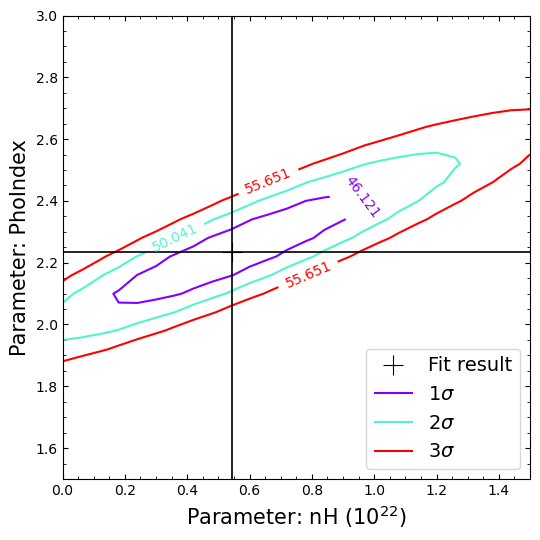

In [32]:
#
plt.figure(figsize=(5.5, 5.5))
plt.minorticks_on()
plt.tick_params(which="both", direction="in", right=True, top=True)

cont_obj = plt.contour(
    steppar_plot_data["nh"],
    steppar_plot_data["powerlaw_ind"],
    steppar_plot_data["contour_height"],
    steppar_plot_data["contour_level"],
    cmap="rainbow",
)
plt.clabel(cont_obj)

plt.xlabel(steppar_plot_data["x_label"], fontsize=15)
plt.ylabel(steppar_plot_data["y_label"], fontsize=15)

fit_point_obj = plt.plot(
    abs_pl_mod.TBabs.nH.values[0],
    abs_pl_mod.powerlaw.PhoIndex.values[0],
    "+",
    color="black",
    markersize=15,
    markeredgewidth=0.8,
)

plt.axvline(
    abs_pl_mod.TBabs.nH.values[0], color="black", linestyle="solid", linewidth=1.2
)
plt.axhline(
    abs_pl_mod.powerlaw.PhoIndex.values[0],
    color="black",
    linestyle="solid",
    linewidth=1.2,
)

cont_handles = cont_obj.legend_elements()[0]

leg_labels = ["Fit result"] + list(cont_conf_perc.keys())
leg_handles = fit_point_obj + cont_handles

plt.legend(leg_handles, leg_labels, fontsize=14, loc=4)

plt.tight_layout()
plt.show()

## 5. Flux calculation

What else can we do with a model fit?

One thing is to derive the flux of the model – the data by themselves only give the
instrument-dependent count rate. The model, on the other hand, is an estimate of the
true spectrum emitted by the astrophysical object. In PyXspec, the model is
defined in physical units independent of the instrument.

### Calling the `calcFlux()` method

The `calcFlux()` method of the model manager `AllModels` (`AllModels` is the way of
operating on all `Model` objects in the same way as `AllData` on all `Spectrum`
objects) integrates the current model over an energy range specified by the
user (2.0–10.0 keV in this case):

In [33]:
xs.AllModels.calcFlux("2.0 10.0")

 Model Flux 0.0035392 photons (2.2324e-11 ergs/cm^2/s) range (2.0000 - 10.000 keV)


From that calculation we can see that the energy flux is
${\sim}2.2 \times 10^{-11} \: \rm{erg}\:\rm{cm}^{-2}\:s^{-1}$.

When calculating the flux in this manner (i.e. not using the method discussed
in [the next subsection](#using-the-cflux-model-component-to-calculate-flux-value-and-uncertainty)),
we can retrieve the current value from the `flux` attribute of the spectrum object:

In [34]:
exo_me_spec.flux[0]

2.232356097423783e-11

Note that `calcFlux()` will integrate only within the energy range of the current
response matrix. If the model flux outside this energy range is desired - in effect, an
extrapolation beyond the data - then the `setEnergies()` method should be used.

This method defines a set of energies on which the models will be calculated. The
resulting models are then remapped onto the response energies for convolution with
the response matrix.

For example, if we want to know the flux of our model in the ROSAT PSPC band
of 0.2–2.0 keV, we enter:

In [35]:
xs.AllModels.setEnergies("extend", "low,0.2,100")
xs.AllModels.calcFlux("0.2 2.0")


Models will use response energies extended to:
   Low:  0.2 in 100 log bins

Fit statistic  : Chi-Squared                   43.82     using 45 bins.

Test statistic : Chi-Squared                   43.82     using 45 bins.
 Null hypothesis probability of 3.94e-01 with 42 degrees of freedom
 Current data and model not fit yet.
 Model Flux 0.0043107 photons (8.8204e-12 ergs/cm^2/s) range (0.20000 - 2.0000 keV)


The energy flux, at ${\sim}8.8\times10^{-12} \: \rm{erg}\:\rm{cm}^{-2}\:s^{-1}$ is
lower in this band, but the photon flux is higher.

Model energies can be reset to the response energies using `xs.AllModels.setEnergies("reset")`.

### Using the _cflux_ model component to calculate flux value and uncertainty

Calculating the flux is not usually enough, we want its uncertainty as well. The best
way to do this is to make use of the _cflux_ model. Suppose further that what we
really want is the **unabsorbed** flux (i.e. what we think the object is emitting
prior to the wider Universe getting in the way) then we redefine the model by:

In [36]:
abs_pl_par_vals = (
    abs_pl_mod(1).values[0],
    abs_pl_mod(2).values[0],
    abs_pl_mod(3).values[0],
)

abs_pl_cflux_mod = xs.Model(
    "tbabs*cflux(powerlaw)",
    setPars=(
        abs_pl_par_vals[0],
        0.2,
        2.0,
        -10.3,
        abs_pl_par_vals[1],
        abs_pl_par_vals[2],
    ),
)


Model TBabs<1>*cflux<2>*powerlaw<3> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.542778     +/-  0.0          
   2    2   cflux      Emin       keV      0.200000     frozen
   3    2   cflux      Emax       keV      2.00000      frozen
   4    2   cflux      lg10Flux   cgs      -10.3000     +/-  0.0          
   5    3   powerlaw   PhoIndex            2.23548      +/-  0.0          
   6    3   powerlaw   norm                1.30164E-02  +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                   51.47     using 45 bins.

Test statistic : Chi-Squared                   51.47     using 45 bins.
 Null hypothesis probability of 1.27e-01 with 41 degrees of freedom
 Current data and model not fit yet.


<br>

The _Emin_ and _Emax_ parameters are set to the energy range over which we want the
flux to be calculated. We also have to fix the normalization of the powerlaw because the
normalization of the model will now be determined by the _lg10Flux_ parameter.

In [37]:
abs_pl_cflux_mod.powerlaw.norm.frozen = True


Fit statistic  : Chi-Squared                   51.47     using 45 bins.

Test statistic : Chi-Squared                   51.47     using 45 bins.
 Null hypothesis probability of 1.50e-01 with 42 degrees of freedom
 Current data and model not fit yet.


Now we run the model fit and calculate the uncertainty on parameter
**four** (_lg10Flux_):

In [38]:
xs.Fit.perform()
xs.Fit.error("4")

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    4:lg10Flux    5:PhoIndex
43.8243      151.428      -3      0.534552      -10.2827       2.23148
43.8215      2.54227      -4      0.542443      -10.2795       2.23541
 Variances and Principal Axes
                 1        4        5  
 3.3544E-05|  0.0637  -0.8010   0.5953  
 3.1291E-03|  0.5102  -0.4865  -0.7092  
 1.0002E-01|  0.8577   0.3489   0.3776  
----------------------------------------

  Covariance Matrix
        1           2           3   
   7.440e-02   2.915e-02   3.126e-02
   2.915e-02   1.294e-02   1.424e-02
   3.126e-02   1.424e-02   1.585e-02
------------------------------------

Model TBabs<1>*cflux<2>*powerlaw<3> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.542443     +/-  0.272755     
   2    2   cflux      Emin       keV      0.200000     frozen
   3    2   cflux      Emax       keV    

<br>

This process tells us that the 90% confidence range (the default when
`error("<par ID>")` is called without further arguments) of the 0.2–2.0 keV unabsorbed
flux is ${\sim}3.5 — 8.3 \: \times 10^{-11} \: \rm{erg}\:\rm{cm}^{-2}\:s^{-1}$.

Usefully, we can also programmatically retrieve the flux value and
just-calculated confidence interval. As _cflux_ is just another component model,
we can access its parameters in the same way we would any other:

In [39]:
cur_flux = Quantity(10 ** abs_pl_cflux_mod.cflux.lg10Flux.values[0], "erg cm^-2 s^-1")
cur_flux

<Quantity 5.25548547e-11 erg / (s cm2)>

In [40]:
cur_flux_conf_inter = 10 ** np.array(abs_pl_cflux_mod.cflux.lg10Flux.error[:2])
cur_flux_conf_inter = Quantity(cur_flux_conf_inter, "erg cm^-2 s^-1")
cur_flux_conf_inter

<Quantity [3.48397207e-11, 8.30567571e-11] erg / (s cm2)>

## 6. Testing alternative spectral models

The absorbed power law fit, as we've remarked, is good, and the parameters are
constrained. However, unless the purpose of our investigation is merely to measure
a photon index, it's a good idea to check whether alternative models can fit the data
just as well.

We also should derive upper limits on components such as iron emission lines and
additional continua, which, although not evident in the data nor required for a good
fit, are nevertheless important to constrain – though we'll get to that
in [Section 7](#7-deriving-upper-limits-on-model-parameters).

### Absorbed blackbody model

First, let's try an absorbed blackbody:

In [41]:
abs_bb_mod = xs.Model("tbabs*bb")
xs.Fit.perform()


Model TBabs<1>*bbody<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   bbody      kT         keV      3.00000      +/-  0.0          
   3    2   bbody      norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              3.375927e+09     using 45 bins.

Test statistic : Chi-Squared              3.375927e+09     using 45 bins.
 Null hypothesis probability of 0.000000e+00 with 42 degrees of freedom
 Current data and model not fit yet.
                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH          2:kT        3:norm
1534.86      63.2544       0      0.338183       3.01571   0.000673480
1523.38      111647        0      0.161649       2.96538   0.000613265
1492.13      170705        0     0.0709727       2.87593   0.000569742
1

78596
 Variances and Principal Axes
                 2        3  
 2.2371E-11| -0.0000   1.0000  
 2.8685E-04|  1.0000   0.0000  
------------------------------

  Covariance Matrix
        1           2   
   2.869e-04   9.352e-09
   9.352e-09   2.268e-11
------------------------

Model TBabs<1>*bbody<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    3.56453E-17  +/-  -1.00000     
   2    2   bbody      kT         keV      0.890224     +/-  1.69367E-02  
   3    2   bbody      norm                2.78596E-04  +/-  4.76190E-06  
________________________________________________________________________


Fit statistic  : Chi-Squared                  123.77     using 45 bins.

Test statistic : Chi-Squared                  123.77     using 45 bins.
 Null hypothesis probability of 5.42e-10 with 42 degrees of freedom


<br>

Note that the fit process has displayed a warning about the first parameter and its
_estimated_ **error is -1**.

Unsurprisingly, this is a bad sign! It indicates that the fit is unable to constrain
the parameter, and it should be considered indeterminate. We can usually interpret this
as meaning that the model is not appropriate.

One thing to check in this case is that the model component has any contribution
within the energy range being calculated.

The black body fit is obviously not a good one. Not only is $\chi^2$ large, but the
best-fitting N$_{\rm H}$ is indeterminate.

When diagnosing a seemingly poor model fit, it is often useful to take a look at
the residuals (like we [already did for the absorbed power law model](#examining-fit-residuals)). To
that end, we once again ask PyXspec to provide the necessary plotting data:

In [42]:
xs.Plot("data resid")

fit_bb_plot_data = {
    "energy": np.array(xs.Plot.x(plotWindow=1)),
    "energy_delta": np.array(xs.Plot.xErr(plotWindow=1)),
    "rate": np.array(xs.Plot.y(plotWindow=1)),
    "rate_err": np.array(xs.Plot.yErr(plotWindow=1)),
    "model": np.array(xs.Plot.model(plotWindow=1)),
    "residual": np.array(xs.Plot.y(plotWindow=2)),
    "residual_err": np.array(xs.Plot.yErr(plotWindow=2)),
}

fit_bb_plot_data["energy_step"] = np.append(
    fit_bb_plot_data["energy"] - fit_bb_plot_data["energy_delta"],
    fit_bb_plot_data["energy"][-1] + fit_bb_plot_data["energy_delta"][-1],
)

Now we plot the data, and inspection of the residuals provides another confirmation
of our belief that the absorbed blackbody model is not a good choice. The
pronounced wave-like shape is **indicative of a bad choice of overall continuum**:

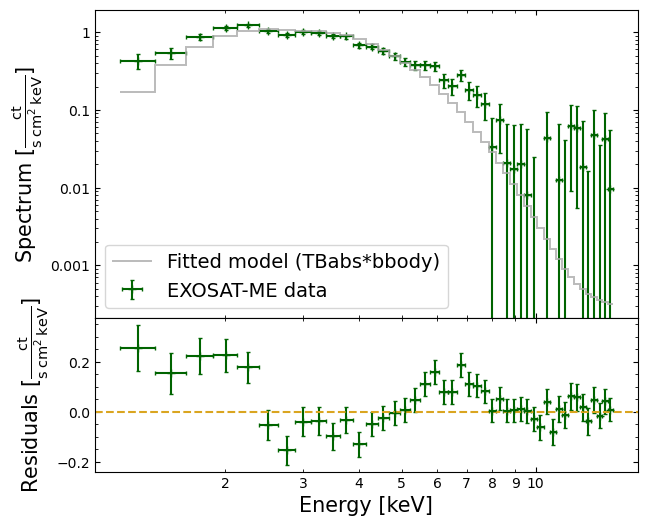

In [43]:
plot_fit_residual_spec(
    fit_bb_plot_data,
    inst_name="EXOSAT-ME",
    mod_expr=abs_bb_mod.expression,
    sp_color="darkgreen",
    res_color="darkgreen",
    mod_color="darkgrey",
)

### Absorbed thermal bremsstrahlung model

Let's try thermal bremsstrahlung next, following the same procedure we did for the
absorbed blackbody in [the last subsection](#absorbed-blackbody-model).

First, we define a model instance and run a fit:

In [44]:
abs_br_mod = xs.Model("tbabs*brems")
xs.Fit.perform()


Model TBabs<1>*bremss<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   bremss     kT         keV      7.00000      +/-  0.0          
   3    2   bremss     norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              4.545115e+07     using 45 bins.

Test statistic : Chi-Squared              4.545115e+07     using 45 bins.
 Null hypothesis probability of 0.000000e+00 with 42 degrees of freedom
 Current data and model not fit yet.
                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH          2:kT        3:norm
104.367      23.8112      -3      0.273915       6.17368    0.00725005
46.6859      16500.6      -4     0.0365477       5.60244    0.00785592
43.1958      5654.35      -5     0.0169395       5.64498    0.00792029


372E-03  +/-  7.37090E-04  
________________________________________________________________________


Fit statistic  : Chi-Squared                   42.33     using 45 bins.

Test statistic : Chi-Squared                   42.33     using 45 bins.
 Null hypothesis probability of 4.57e-01 with 42 degrees of freedom


<br>

Now we extract the data necessary to plot the fitted spectrum and residuals:

In [45]:
xs.Plot("data resid")

fit_br_plot_data = {
    "energy": np.array(xs.Plot.x(plotWindow=1)),
    "energy_delta": np.array(xs.Plot.xErr(plotWindow=1)),
    "rate": np.array(xs.Plot.y(plotWindow=1)),
    "rate_err": np.array(xs.Plot.yErr(plotWindow=1)),
    "model": np.array(xs.Plot.model(plotWindow=1)),
    "residual": np.array(xs.Plot.y(plotWindow=2)),
    "residual_err": np.array(xs.Plot.yErr(plotWindow=2)),
}

fit_br_plot_data["energy_step"] = np.append(
    fit_br_plot_data["energy"] - fit_br_plot_data["energy_delta"],
    fit_br_plot_data["energy"][-1] + fit_br_plot_data["energy_delta"][-1],
)

Finally, we make a visualization:

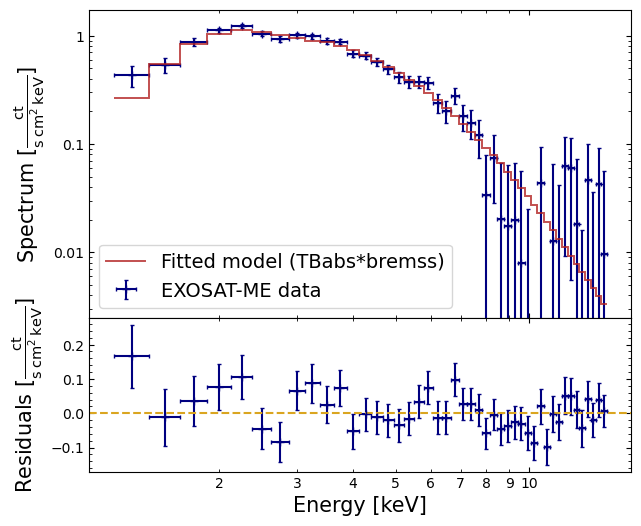

In [46]:
plot_fit_residual_spec(
    fit_br_plot_data, inst_name="EXOSAT-ME", mod_expr=abs_br_mod.expression
)

It is clear that the Bremsstrahlung model is a better fit than the blackbody – and is
as good as the power law – although it shares the low absorption column.

### Absorbed power law model [frozen nH]

With two models that appear to be good fits to the spectrum (absorbed power law and
absorbed Bremsstrahlung), it's time to scrutinize their parameters in more detail.

From the EXOSAT database on HEASARC, we know that the target in question,
**1E1048.1-5937**, is almost on the plane of the Galaxy. In fact, the database also
provides values for the Galactic N$_{\rm H}$ based on 21-cm radio observations.

One estimate (though admittedly not the one you will get from the current version
of `nhtool`) puts it at $4\times10^{22}$ cm$^{-2}$, which is higher than the 90%
confidence upper limit from the power-law fit.

Perhaps, then, the power-law fit is not so good after all. What
we can do is fix (freeze in XSPEC terminology) the value of N$_{\rm H}$ at the
Galactic value and refit the power law. Although we won't get a good fit, the shape
of the residuals might give us a clue to what is missing.

We follow a familiar procedure, though here we make sure to freeze the value of
the Hydrogen column density at the estimate we're using:

In [47]:
abs_pl_frz_nh_mod = xs.Model("tbabs*powerlaw")

abs_pl_frz_nh_mod.TBabs.nH = 4.0
abs_pl_frz_nh_mod.TBabs.nH.frozen = True

xs.Fit.perform()


Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              4.859538e+08     using 45 bins.

Test statistic : Chi-Squared              4.859538e+08     using 45 bins.
 Null hypothesis probability of 0.000000e+00 with 42 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared              3.207240e+08     using 45 bins.

Test statistic : Chi-Squared              3.207240e+08     using 45 bins.
 Null hypothesis probability of 0.000000e+00 with 42 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared              3.207240e+08     using 45 

0.00381578
935.643      40104.6      -1       1.56254    0.00582512
766.041      31426.4      -1       1.80268    0.00873216
622.228      19892.6      -1       2.01612     0.0124867
507.734      12157.1      -1       2.20659     0.0170071
418.397      7544.3       -1       2.37673     0.0221916
416.213      4814.65      -2       3.05221     0.0440337
309.299      7466.95      -3       3.59154     0.0891606
134.291      3400.36      -4       3.57479      0.113292
134.227      66.1577      -5       3.57576      0.112938
134.227      0.0772422    -6       3.57595      0.112962
 Variances and Principal Axes
                 2        3  
 3.6240E-06| -0.1311   0.9914  
 4.6299E-03|  0.9914   0.1311  
------------------------------

  Covariance Matrix
        1           2   
   4.550e-03   6.011e-04
   6.011e-04   8.308e-05
------------------------

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH    

<br>

Then fetching the information necessary to plot a fitted spectrum and residuals:

In [48]:
xs.Plot("data resid")

fit_pl_frz_nh_plot_data = {
    "energy": np.array(xs.Plot.x(plotWindow=1)),
    "energy_delta": np.array(xs.Plot.xErr(plotWindow=1)),
    "rate": np.array(xs.Plot.y(plotWindow=1)),
    "rate_err": np.array(xs.Plot.yErr(plotWindow=1)),
    "model": np.array(xs.Plot.model(plotWindow=1)),
    "residual": np.array(xs.Plot.y(plotWindow=2)),
    "residual_err": np.array(xs.Plot.yErr(plotWindow=2)),
}

fit_pl_frz_nh_plot_data["energy_step"] = np.append(
    fit_pl_frz_nh_plot_data["energy"] - fit_pl_frz_nh_plot_data["energy_delta"],
    fit_pl_frz_nh_plot_data["energy"][-1] + fit_pl_frz_nh_plot_data["energy_delta"][-1],
)

Finally, making a visualization:

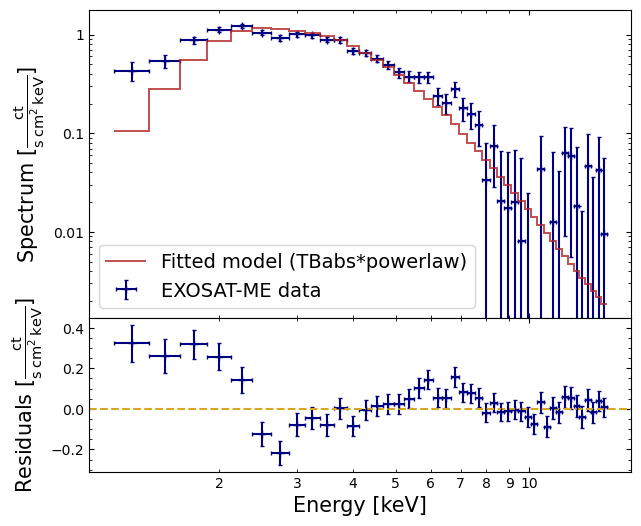

In [49]:
plot_fit_residual_spec(
    fit_pl_frz_nh_plot_data,
    inst_name="EXOSAT-ME",
    mod_expr=abs_pl_frz_nh_mod.expression,
)

In this version of the absorbed power-law fit, there appears to be an observational
surplus of softer photons, perhaps indicating a second continuum component needs to
be modeled.

### Absorbed power law + blackbody model [frozen nH]

To investigate this possibility, we can combine what we have with another additive
model component; a _bbody_.

Note that we freeze the temperature parameter of the black body to 2 keV (the canonical
temperature for nuclear burning on the surface of a neutron star in a low-mass
X-ray binary) using an XSPEC trick that setting the delta for a parameter to zero
switches its freeze/thaw status.

We also set the normalization of the component to a small number to start the fit
off in a sensible place since we are looking for a small change to the model.

In [50]:
abs_pl_frz_nh_par_vals = (
    abs_pl_frz_nh_mod(1).values[0],
    abs_pl_frz_nh_mod(2).values[0],
    abs_pl_frz_nh_mod(3).values[0],
)

abs_pl_bb_frz_nh_mod = xs.Model(
    "tbabs(powerlaw+bb)",
    setPars=(
        abs_pl_frz_nh_par_vals[0],
        abs_pl_frz_nh_par_vals[1],
        abs_pl_frz_nh_par_vals[2],
        "2.0,0.0",
        1.0e-5,
    ),
)

abs_pl_bb_frz_nh_mod.TBabs.nH.frozen = True


Model TBabs<1>(powerlaw<2> + bbody<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    4.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            3.57595      +/-  0.0          
   3    2   powerlaw   norm                0.112962     +/-  0.0          
   4    3   bbody      kT         keV      2.00000      frozen
   5    3   bbody      norm                1.00000E-05  +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                  131.04     using 45 bins.

Test statistic : Chi-Squared                  131.04     using 45 bins.
 Null hypothesis probability of 2.41e-11 with 41 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                  131.04     using 45 bins.

Test statistic : Chi-Squared                  131.04     using 45 bins.
 Null hypothesis probability of 4.38e-11

<br>

We run the fit of this new two-continua-component model:

In [51]:
xs.Fit.perform()

                                   Parameters
Chi-Squared  |beta|/N    Lvl    2:PhoIndex        3:norm        5:norm
129.066      53855.5      -3       4.47679      0.198877   0.000244340
90.8792      7260.12      -4       4.87139      0.317929   0.000225711
69.2353      84957.5      -5       4.86527      0.350685   0.000229422
69.2346      556.179      -6       4.86485      0.350373   0.000229320
 Variances and Principal Axes
                 2        3        5  
 1.1861E-10| -0.0003   0.0008   1.0000  
 7.6889E-05|  0.2988  -0.9543   0.0008  
 2.7853E-02|  0.9543   0.2988   0.0001  
----------------------------------------

  Covariance Matrix
        1           2           3   
   2.537e-02   7.920e-03   2.545e-06
   7.920e-03   2.557e-03   7.303e-07
   2.545e-06   7.303e-07   4.224e-10
------------------------------------

Model TBabs<1>(powerlaw<2> + bbody<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         

129.066      53855.5      -3       4.47679      0.198877   0.000244340
90.8792      7260.12      -4       4.87139      0.317929   0.000225711
69.2353      84957.5      -5       4.86527      0.350685   0.000229422
69.2346      556.179      -6       4.86485      0.350373   0.000229320
 Variances and Principal Axes
                 2        3        5  
 1.1861E-10| -0.0003   0.0008   1.0000  
 7.6889E-05|  0.2988  -0.9543   0.0008  
 2.7853E-02|  0.9543   0.2988   0.0001  
----------------------------------------

  Covariance Matrix
        1           2           3   
   2.537e-02   7.920e-03   2.545e-06
   7.920e-03   2.557e-03   7.303e-07
   2.545e-06   7.303e-07   4.224e-10
------------------------------------

Model TBabs<1>(powerlaw<2> + bbody<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    4.00000      frozen
   2    2   powerlaw   PhoIndex            4.86485      +/-  0.159289     
   3    2   p

The fit is better than the one with just a power law and the fixed Galactic
column, but it is still not good. Thawing the black body temperature and fitting
does of course improve the fit, but the power law index becomes even steeper.

Now we have two separate additive models contributing to the continuum fit, we might
want to examine their individual contributions to this odd model.

To do that, we're going to make yet another version of a fitted spectrum
visualization. This time though we're going to drop the residual panel, and
retrieve/plot both the overall model, and the curves of the individual model components.

For this to work, we have to tell PyXspec to calculate the plotting information for
individual additive model components as well as the usual total model:

In [52]:
xs.Plot.add = True

Now we fetch much the same data as we have previously, but this time also use
the `Plot.addComp(<additive model ID>)` method to retrieve the plotting information
for the individual model components:

In [53]:
xs.Plot("data")

fit_pl_bb_plot_data = {
    "energy": np.array(xs.Plot.x()),
    "energy_delta": np.array(xs.Plot.xErr()),
    "rate": np.array(xs.Plot.y()),
    "rate_err": np.array(xs.Plot.yErr()),
    "total_model": np.array(xs.Plot.model()),
    "powerlaw_model": np.array(xs.Plot.addComp(1)),
    "bbody_model": np.array(xs.Plot.addComp(2)),
}

fit_pl_bb_plot_data["energy_step"] = np.append(
    fit_pl_bb_plot_data["energy"] - fit_pl_bb_plot_data["energy_delta"],
    fit_pl_bb_plot_data["energy"][-1] + fit_pl_bb_plot_data["energy_delta"][-1],
)

Now we can visualize the spectrum and the two-additive-model fit:

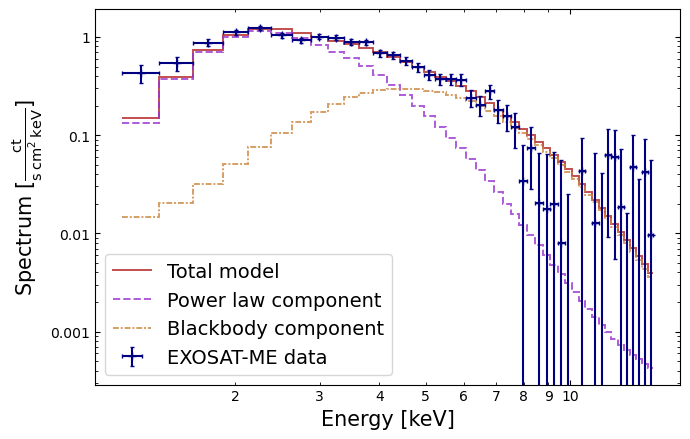

In [54]:
plt.figure(figsize=(7, 4.5))
plt.minorticks_on()
plt.tick_params(which="both", direction="in", top=True, right=True)

# Set the colours for each component we're plotting
cur_sp_color = "navy"
cur_tot_mod_color = "firebrick"
cur_pl_mod_color = "darkorchid"
cur_bb_mod_color = "peru"

# Then set the linestyles
cur_tot_mod_ls = "solid"
cur_pl_mod_ls = "dashed"
cur_bb_mod_ls = (0, (3, 1, 1, 1))

# This adds the spectrum data points to the figure
plt.errorbar(
    fit_pl_bb_plot_data["energy"],
    fit_pl_bb_plot_data["rate"],
    xerr=fit_pl_bb_plot_data["energy_delta"],
    yerr=fit_pl_bb_plot_data["rate_err"],
    fmt="+",
    capsize=1.5,
    label="EXOSAT-ME data",
    color=cur_sp_color,
)

# Total model
plt.stairs(
    fit_pl_bb_plot_data["total_model"],
    fit_pl_bb_plot_data["energy_step"],
    baseline=None,
    fill=False,
    color=cur_tot_mod_color,
    alpha=0.8,
    label="Total model",
    linewidth=1.4,
    linestyle=cur_tot_mod_ls,
)

# Power law model component
plt.stairs(
    fit_pl_bb_plot_data["powerlaw_model"],
    fit_pl_bb_plot_data["energy_step"],
    baseline=None,
    fill=False,
    color=cur_pl_mod_color,
    alpha=0.8,
    label="Power law component",
    linewidth=1.4,
    linestyle=cur_pl_mod_ls,
)

# Bremsstrahlung model component
plt.stairs(
    fit_pl_bb_plot_data["bbody_model"],
    fit_pl_bb_plot_data["energy_step"],
    baseline=None,
    fill=False,
    color=cur_bb_mod_color,
    alpha=0.8,
    label="Blackbody component",
    linewidth=1.4,
    linestyle=cur_bb_mod_ls,
)

# Set the axis scales
plt.xscale("log")
plt.yscale("log")

# Here we tell matplotlib how to format the labels it applies to the ticks on
#  each axis; e.g. should we see 10^2 or 100. This configures the tick labels to
#  avoid scientific notation (i.e. 100 instead of 10^2)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))
plt.gca().xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda inp, _: "{:g}".format(inp)))

# Add the x and y axis labels
plt.xlabel("Energy [keV]", fontsize=15)
plt.ylabel(
    r"Spectrum [$\frac{\rm{ct}}{\rm{s} \: \rm{cm}^{2} \: \rm{keV}}$]", fontsize=15
)

plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

We see that the black body and the power law have changed places, in that the power
law provides the soft photons required by the high absorption, while the black body
provides the harder photons. We could continue to search for a plausible, well-fitting
model, but the data, with their limited signal-to-noise and energy resolution, probably
don't warrant it (the original investigators published only the power law fit).

## 7. Deriving upper limits on model parameters

There is one final useful thing to do with the data – derive an upper limit
to the presence of a fluorescent iron emission line. We return to our original model
and add a gaussian emission line of fixed energy and width then fit to get:

In [55]:
abs_pl_gauss_em_mod = xs.Model(
    "tbabs*(powerlaw + gaussian)", setPars=(1.0, 1.0, 1.0, "6.4,0.0", "0.1,0.0", 1.0e-4)
)
xs.Fit.perform()


Model TBabs<1>(powerlaw<2> + gaussian<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
   4    3   gaussian   LineE      keV      6.40000      frozen
   5    3   gaussian   Sigma      keV      0.100000     frozen
   6    3   gaussian   norm                1.00000E-04  +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              4.860175e+08     using 45 bins.

Test statistic : Chi-Squared              4.860175e+08     using 45 bins.
 Null hypothesis probability of 0.000000e+00 with 41 degrees of freedom
 Current data and model not fit yet.
                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    2:PhoIndex        3:

<br>

The energy and width have to be frozen because, in the absence of an obvious line in
the data, the fit would be completely unable to converge on meaningful
values. Besides, our aim is to see how bright a line at 6.4 keV can be and still
not ruin the fit. To do this, we fit first and then use the error command to derive
the maximum allowable iron line normalization. We then set the normalization at this
maximum value with and, finally, derive the equivalent width. That is:

In [56]:
xs.Fit.error("6")

 Parameter   Confidence Range (2.706)
***Warning: Parameter pegged at hard limit: 0
     6            0  0.000151008    (-7.46043e-05,7.6404e-05)


<br>

Note that the true minimum value of the gaussian normalization is less than zero, but
the error search stopped when the minimum value hit zero, the "hard" lower limit of
the parameter.

In [57]:
abs_pl_gauss_em_mod.gaussian.norm = abs_pl_gauss_em_mod.gaussian.norm.error[1]


Fit statistic  : Chi-Squared                   46.06     using 45 bins.

Test statistic : Chi-Squared                   46.06     using 45 bins.
 Null hypothesis probability of 2.71e-01 with 41 degrees of freedom
 Current data and model not fit yet.


The `eqwidth()` method takes the component number as its argument:

In [58]:
xs.AllModels.eqwidth("3")


Data group number: 1
Additive group equiv width for Component 3:  0.78255 keV


Additive group equiv width for Component 3:  0.78255 keV


## About this notebook

Author: Keith Arnaud, XSPEC Lead, Associate Research Scientist

Author: David Turner, HEASARC Staff Scientist

Updated On: 2026-06-01

### Additional Resources

Support: [XSPEC Helpdesk](https://heasarc.gsfc.nasa.gov/cgi-bin/Feedback?selected=xspec)

[Original PyXspec Jupyter Notebooks Repository](https://github.com/HEASARC/PyXspec-Jupyter-notebooks)

[Full XSPEC walkthrough dataset](https://heasarc.gsfc.nasa.gov/FTP/software/xspec/walkthrough.tar.gz)

[XSPEC plot devices](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/XScpd.html)

[XSPEC plot types](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/XSplot.html)

[XSPEC **convolution** models](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/Convolution.html)

[XSPEC **mixing** models](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/Mixing.html)

[Parallelization settings in PyXspec](https://heasarc.gsfc.nasa.gov/docs/software/xspec/python/html/xspecsettings.html)

[XSPEC `tclout` API reference](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/XStclout.html)

[XSPEC `steppar` command](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/XSsteppar.html)

### Acknowledgements

### References

[Seward F. D., Charles P. A., Smale A. P. (1986)](https://ui.adsabs.harvard.edu/abs/1986ApJ...305..814S/abstract) - _A 6 Second Periodic X-Ray Source in Carina_